# 📊 Sessão 02 — Análise Exploratória de Dados (EDA) do PEF Vinhedo

> **Objetivo:** explorar profundamente o dataset florestal através de distribuições, correlações, detecção de outliers e perfis por classe de sítio, estabelecendo o entendimento estatístico que guiará a modelagem nas sessões seguintes.

---

## 📑 Sumário

1. [Setup](#1-setup)
2. [Carregamento e Visão Geral](#2-carregamento-e-visão-geral)
3. [Distribuições Univariadas](#3-distribuições-univariadas)
4. [Correlações entre Variáveis](#4-correlações-entre-variáveis)
5. [Relações Bivariadas Fundamentais](#5-relações-bivariadas-fundamentais)
6. [Análise por Classe de Sítio](#6-análise-por-classe-de-sítio)
7. [Detecção de Outliers](#7-detecção-de-outliers)
8. [Síntese e Próximos Passos](#8-síntese-e-próximos-passos)

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from forestpy.data.loaders import load_pef_vinhedo
from forestpy.utils import set_seed, get_logger
from forestpy.viz.style import apply_forest_style
from forestpy.viz.eda import (
    plot_distribution_grid,
    plot_correlation_heatmap,
    plot_boxplot_by_group,
)
from forestpy.viz.trees import plot_scatter_relationship

set_seed(42)
apply_forest_style()
log = get_logger('sessao_02')
log.info('Setup concluído.')

[16:33:37] INFO     Setup concluído.

## 2. Carregamento e Visão Geral

In [2]:
df = load_pef_vinhedo(synthetic_fallback=True, n_synthetic=500)
log.info(f'Dataset: {df.shape[0]} árvores × {df.shape[1]} variáveis')
df.head()

[16:33:42] INFO     Dataset: 500 árvores × 9 variáveis

,parcela,arvore,especie,dap,h,h_com,idade,classe,volume
0,28,1,Eucalyptus grandis,29.92,14.58,11.96,5,I,0.6698
1,23,2,Eucalyptus grandis,35.48,28.65,25.10,7,III,2.0598
2,11,3,Eucalyptus grandis,32.25,24.48,22.52,10,II,1.3736
3,30,4,Eucalyptus grandis,14.35,9.35,8.56,5,II,0.0974
4,13,5,Eucalyptus grandis,21.03,20.38,16.80,10,II,0.5072


In [3]:
# Estatísticas descritivas completas
df.describe().round(2)

,parcela,arvore,dap,h,h_com,idade,volume
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,15.40,250.50,19.63,14.98,13.23,6.32,0.45
std,8.68,144.48,8.67,5.81,5.16,2.16,0.59
min,1.00,1.00,5.00,3.02,2.67,3.00,0.00
25%,8.00,125.75,13.20,10.74,9.41,5.00,0.11
50%,15.00,250.50,18.24,14.20,12.46,7.00,0.25
75%,23.00,375.25,24.48,18.28,16.23,7.00,0.57
max,30.00,500.00,50.00,40.74,36.32,10.00,5.12


**Variáveis numéricas para análise:** `dap`, `h`, `h_com`, `idade`, `volume`.

A seguir, exploramos cada uma em detalhe.

## 3. Distribuições Univariadas

**📈 Figura 1** — Histogramas com KDE para entender a forma de cada distribuição (assimetria, multimodalidade, amplitude).

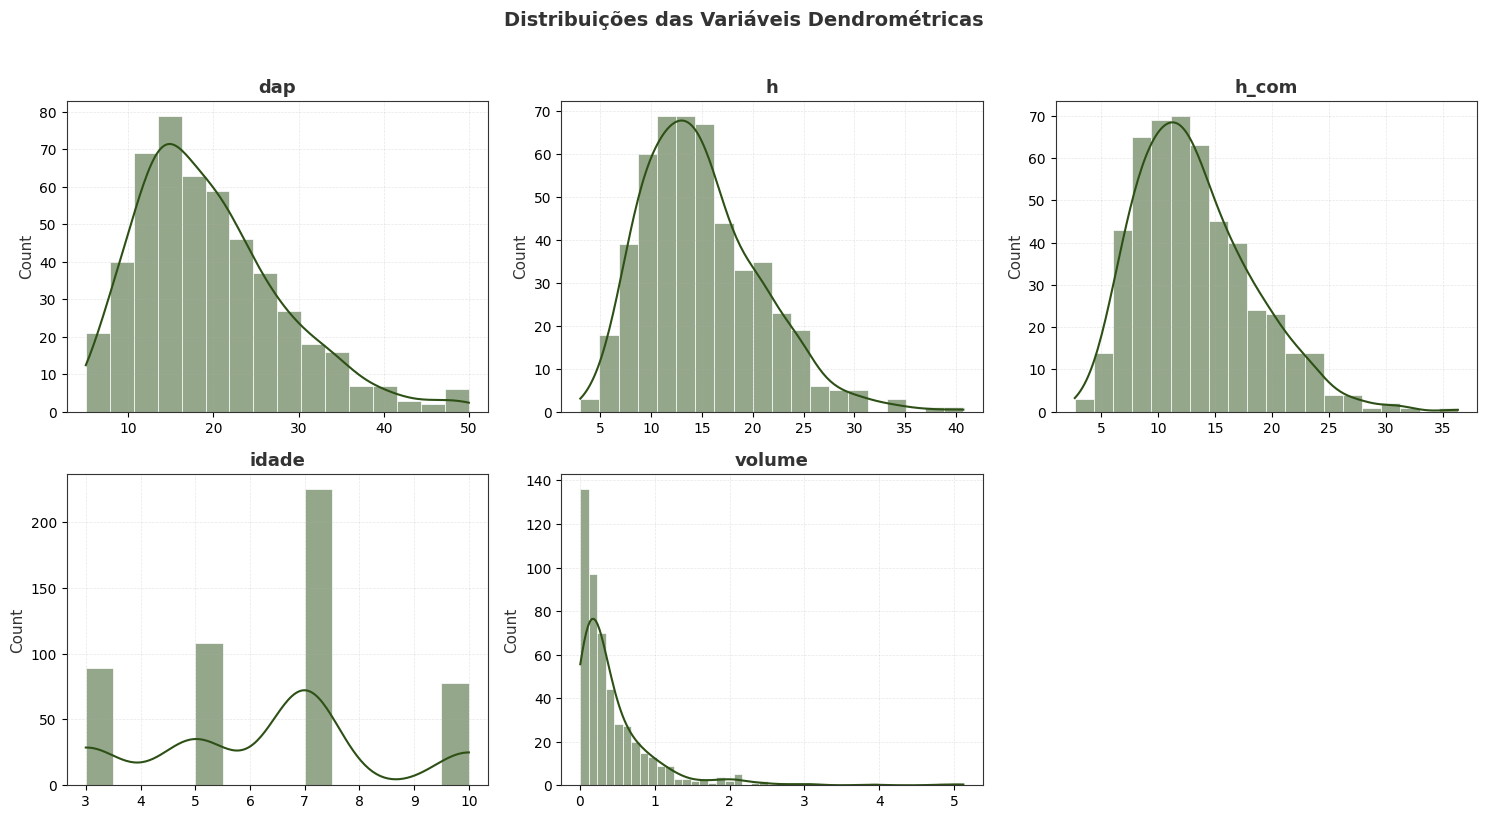

In [4]:
fig1 = plot_distribution_grid(
    df,
    cols=['dap', 'h', 'h_com', 'idade', 'volume'],
    ncols=3,
    title='Distribuições das Variáveis Dendrométricas',
)
fig1.savefig('../reports/figures/02_distribuicoes.png')
plt.show()

**🔍 Interpretação esperada:**
- **DAP**: distribuição assimétrica à direita (típica de Gama) — muitas árvores médias, poucas grossas
- **Altura**: aproximadamente normal, levemente assimétrica
- **Idade**: discreta (3, 5, 7, 10 anos) — variável categórica disfarçada de numérica
- **Volume**: forte assimetria à direita (volume cresce com potência do DAP)

## 4. Correlações entre Variáveis

**📈 Figura 2** — Heatmap de correlação de Pearson. Identifica multicolinearidade (importante para escolher features dos modelos).

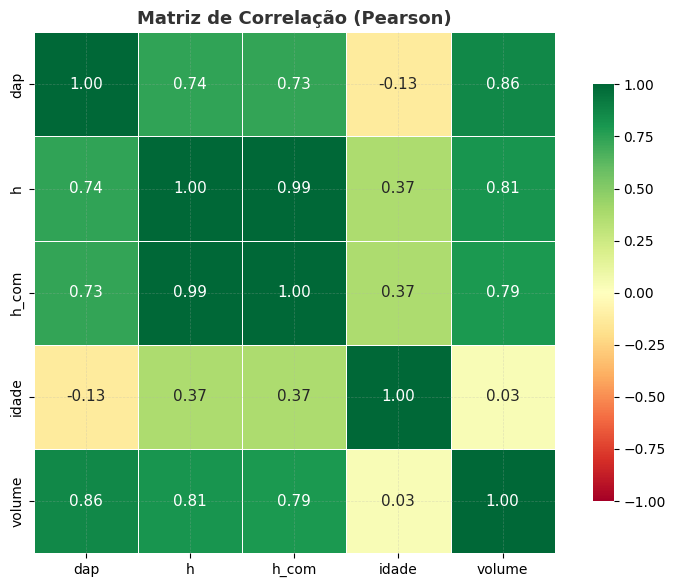

In [5]:
fig2 = plot_correlation_heatmap(
    df[['dap', 'h', 'h_com', 'idade', 'volume']],
    method='pearson',
    title='Matriz de Correlação (Pearson)',
)
fig2.savefig('../reports/figures/02_correlacao.png')
plt.show()

**🔍 Interpretação esperada:**
- **DAP × Volume**: correlação altíssima (>0.9) — DAP é o melhor preditor de volume
- **H × Volume**: correlação forte, mas menor que DAP
- **H × H_com**: correlação quase perfeita (h_com é derivado de h) → **redundância**, usar apenas uma nos modelos

## 5. Relações Bivariadas Fundamentais

**📈 Figura 3** — A relação **DAP × Altura** é a base da hipsometria (Sessão 07).

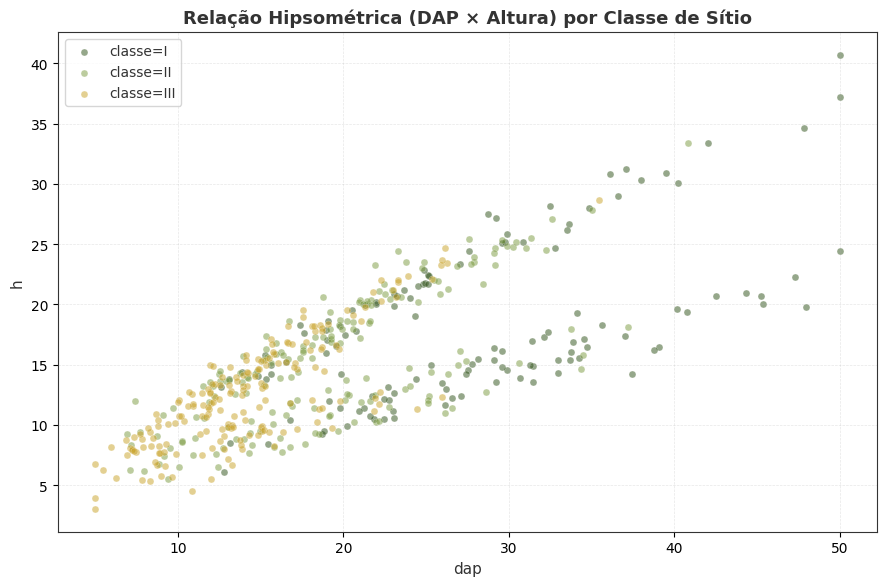

In [6]:
fig3 = plot_scatter_relationship(
    df, x_col='dap', y_col='h', hue_col='classe',
    title='Relação Hipsométrica (DAP × Altura) por Classe de Sítio',
)
fig3.savefig('../reports/figures/02_dap_altura.png')
plt.show()

**📈 Figura 4** — A relação **DAP × Volume** é a base da volumetria (Sessões 05-06).

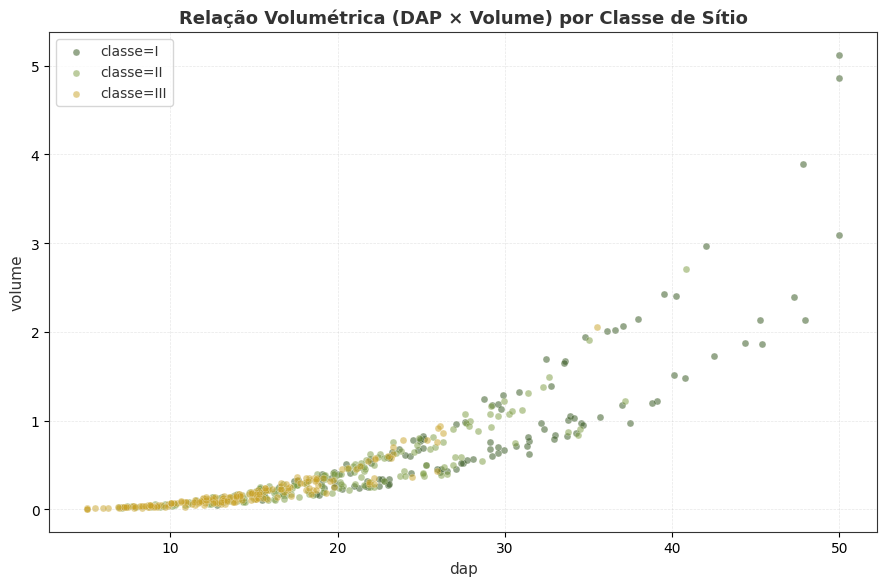

In [7]:
fig4 = plot_scatter_relationship(
    df, x_col='dap', y_col='volume', hue_col='classe',
    title='Relação Volumétrica (DAP × Volume) por Classe de Sítio',
)
fig4.savefig('../reports/figures/02_dap_volume.png')
plt.show()

## 6. Análise por Classe de Sítio

**📈 Figura 5** — Boxplots de altura por classe revelam a separação de produtividade.

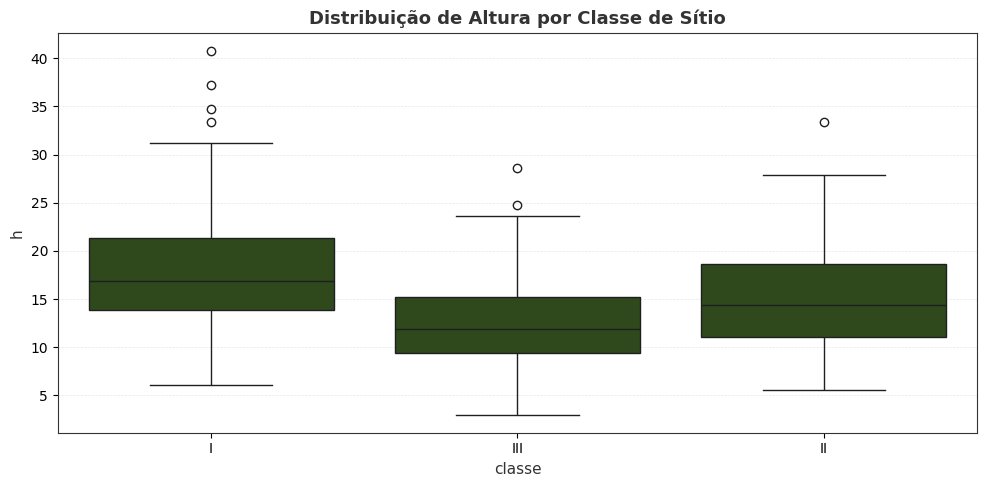

In [8]:
fig5 = plot_boxplot_by_group(
    df, value_col='h', group_col='classe',
    title='Distribuição de Altura por Classe de Sítio',
)
fig5.savefig('../reports/figures/02_altura_classe.png')
plt.show()

In [9]:
# Tabela resumo por classe
resumo = df.groupby('classe').agg(
    n=('arvore', 'count'),
    dap_medio=('dap', 'mean'),
    h_media=('h', 'mean'),
    volume_medio=('volume', 'mean'),
).round(2)
resumo

,n,dap_medio,h_media,volume_medio
classe,,,,
I,128,27.90,18.22,0.91
II,180,19.43,15.25,0.40
III,192,14.30,12.56,0.19


## 7. Detecção de Outliers

**📈 Figura 6** — Método IQR (Intervalo Interquartil) para flagar valores atípicos em cada variável.

In [10]:
def detectar_outliers_iqr(serie: pd.Series) -> pd.Series:
    """Retorna máscara booleana de outliers pelo método IQR (1.5×)."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    return (serie < limite_inf) | (serie > limite_sup)

# Conta outliers por variável
for col in ['dap', 'h', 'volume']:
    n_out = detectar_outliers_iqr(df[col]).sum()
    pct = 100 * n_out / len(df)
    log.info(f'{col:8s}: {n_out:3d} outliers ({pct:.1f}%)')

[16:34:19] INFO     dap     :  11 outliers (2.2%)

           INFO     h       :  10 outliers (2.0%)

           INFO     volume  :  32 outliers (6.4%)

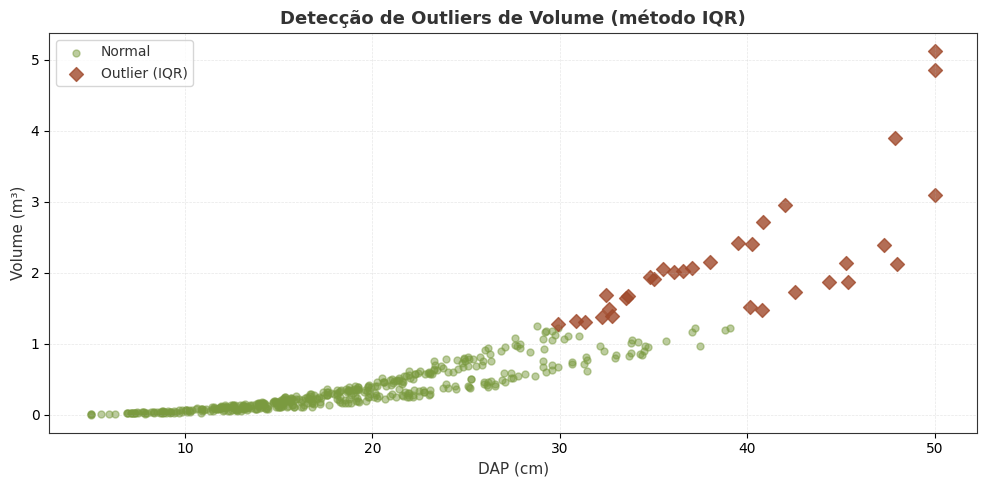

In [11]:
# Visualização dos outliers de volume
fig6, ax = plt.subplots(figsize=(10, 5))
outliers_vol = detectar_outliers_iqr(df['volume'])
ax.scatter(df.loc[~outliers_vol, 'dap'], df.loc[~outliers_vol, 'volume'],
           alpha=0.5, s=25, label='Normal', color='#7a9a3f')
ax.scatter(df.loc[outliers_vol, 'dap'], df.loc[outliers_vol, 'volume'],
           alpha=0.8, s=50, label='Outlier (IQR)', color='#a04a2c', marker='D')
ax.set_xlabel('DAP (cm)')
ax.set_ylabel('Volume (m³)')
ax.set_title('Detecção de Outliers de Volume (método IQR)', fontweight='bold')
ax.legend()
fig6.tight_layout()
fig6.savefig('../reports/figures/02_outliers.png')
plt.show()

## 8. Síntese e Próximos Passos

### 📋 Principais achados

| Achado | Implicação para a modelagem |
|--------|------------------------------|
| DAP tem distribuição assimétrica (Gama) | Considerar transformação log nos modelos lineares |
| DAP × Volume com correlação >0.9 | DAP será o preditor primário de volume |
| H e H_com são redundantes | Usar apenas uma para evitar multicolinearidade |
| Classes de sítio bem separadas | Variável `classe` é informativa como feature categórica |
| Outliers ~5% (ruído de medição simulado) | Manter — refletem variabilidade real de campo |

### 🎯 Próxima sessão (03): Dendrometria Clássica

Vamos **ajustar** as equações de volume (Schumacher-Hall, Spurr, Honer) aos dados, estimando os coeficientes reais por mínimos quadrados e comparando a qualidade de ajuste — estabelecendo o **baseline clássico** que as Redes Neurais (Sessão 06) tentarão superar.